In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
data=pd.read_csv("amazon.csv")
display(data.head(3))

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [101]:
print(f"Data has {data.shape[0]} rows and {data.shape[1]} columns")

Data has 1465 rows and 16 columns


In [102]:
print("Columns present in the Data are\n",data.columns)

Columns present in the Data are
 Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


In [103]:
print("Data Type of colimns are as below\n\n",data.dtypes)

Data Type of colimns are as below

 product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object


In [104]:
data.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [105]:
data["rating_count"].dtype

dtype('O')

In [106]:
data["rating_count"]=data["rating_count"].str.replace(",","").astype("float")
data["rating_count"].dtype

dtype('float64')

In [107]:
data["rating_count"].fillna(data["rating_count"].mean(numeric_only=True))
data.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [108]:
data["discounted_price"]=data["discounted_price"].str.replace("₹","").str.replace(",","").astype("float")
data["discounted_price"].dtype

dtype('float64')

In [109]:
data["actual_price"]=data["actual_price"].str.replace("₹","").str.replace(",","").astype("float")
data["actual_price"].dtype

dtype('float64')

In [110]:
data["discount_percentage"]=data["discount_percentage"].str.replace("%","").astype(int)

In [111]:
print(f"Number of product has more than 50% discount are {(data["discount_percentage"]>50).sum()}")

Number of product has more than 50% discount are 695


In [112]:
print(f"Product haveing most reviews are:\n{data["rating_count"].sort_values(ascending=False).head(10)}")

Product haveing most reviews are:
12     426973.0
65     426973.0
47     426973.0
684    426972.0
400    363713.0
352    363713.0
584    363711.0
371    313836.0
370    313836.0
566    313832.0
Name: rating_count, dtype: float64


In [113]:
data['rating'] = data['rating'].str.replace('|', '.').str.strip()
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data.dropna(subset=['rating'], inplace=True)

In [114]:
data.groupby("category")["rating"].mean(numeric_only=True)

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    3.800000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                   4.150000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                           3.500000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                        3.600000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                           4.050000
                                                                                                                            ...   
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens        4.250000
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSu

In [115]:
data.groupby("category")["discounted_price"].mean(numeric_only=True)

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    2339.000000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                    221.500000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                            649.000000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                         574.000000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                            749.000000
                                                                                                                             ...     
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens         150.000000
OfficeProducts|OfficePaperProducts|Paper|Stationery|P

In [116]:
data.groupby("category")["actual_price"].mean(numeric_only=True)

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    4000.000000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                   2699.000000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                            999.000000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                        1249.500000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                           1399.500000
                                                                                                                             ...     
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens         150.000000
OfficeProducts|OfficePaperProducts|Paper|Stationery|P

In [117]:
print("Mean   :", np.mean(data['rating']))
print("Median :", np.median(data['rating']))
print("Std Dev:", np.std(data['rating']))
print("Max    :", np.max(data['rating']))

Mean   : 4.096584699453552
Median : 4.1
Std Dev: 0.2915744469711793
Max    : 5.0


In [118]:
correlation = data['discount_percentage'].corr(data['rating'])
print("Correlation between Discount % and Rating:", correlation)

Correlation between Discount % and Rating: -0.15537543972693033


Text(0, 0.5, 'Rating')

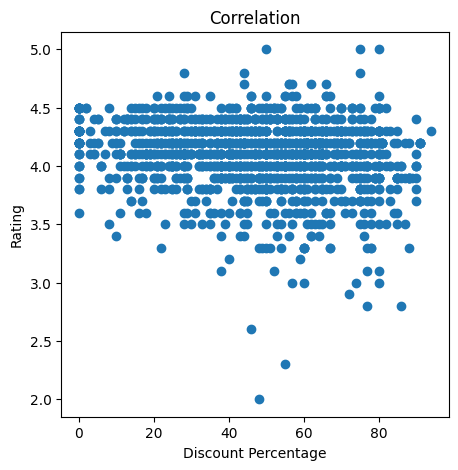

In [119]:
plt.figure(figsize=(5,5))
plt.scatter(data["discount_percentage"],data["rating"])
plt.title("Correlation")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")

Text(0, 0.5, 'No Of Times')

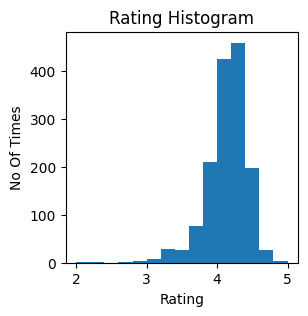

In [120]:
plt.figure(figsize=(3,3))
plt.hist(data["rating"],bins=15)
plt.title("Rating Histogram")
plt.xlabel("Rating")
plt.ylabel("No Of Times")

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Electronics'),
  Text(1, 0, 'Computers&Accessories'),
  Text(2, 0, 'Home&Kitchen'),
  Text(3, 0, 'OfficeProducts'),
  Text(4, 0, 'MusicalInstruments'),
  Text(5, 0, 'HomeImprovement'),
  Text(6, 0, 'Toys&Games'),
  Text(7, 0, 'Car&Motorbike'),
  Text(8, 0, 'Health&PersonalCare')])

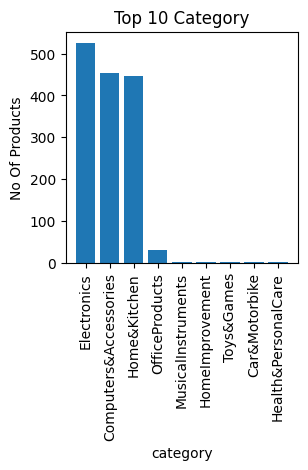

In [121]:
top_category = data["category"].str.split("|").str[0].value_counts().head(10)

plt.figure(figsize=(3,3))
plt.bar(top_category.index,top_category.values);
plt.title("Top 10 Category")
plt.xlabel("category")
plt.ylabel("No Of Products")
plt.xticks(rotation=90)

(array([], dtype=float64), [])

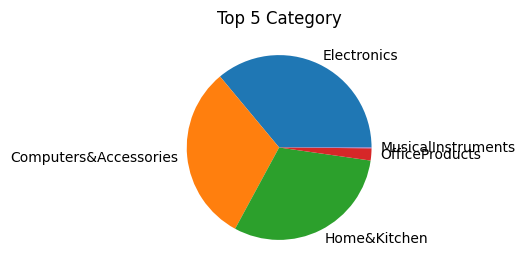

In [127]:
top_5=data["category"].str.split("|").str[0].value_counts().head(5)

plt.figure(figsize=(3,3))
plt.pie(top_5,labels=top_5.index);
plt.title("Top 5 Category")
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Electronics'),
  Text(1, 0, 'Computers&Accessories'),
  Text(2, 0, 'Home&Kitchen'),
  Text(3, 0, 'OfficeProducts'),
  Text(4, 0, 'MusicalInstruments'),
  Text(5, 0, 'HomeImprovement'),
  Text(6, 0, 'Toys&Games'),
  Text(7, 0, 'Car&Motorbike')])

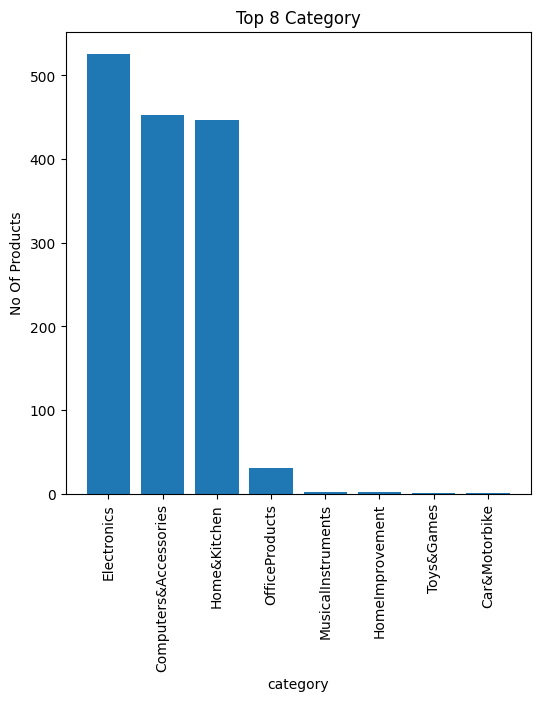

In [129]:
top_8=data["category"].str.split("|").str[0].value_counts().head(8)

plt.figure(figsize=(6,6))
plt.bar(top_8.index,top_8.values);
plt.title("Top 8 Category")
plt.xlabel("category")
plt.ylabel("No Of Products")
plt.xticks(rotation=90)